Validating Environment

In [27]:
try:
    import numpy as np
    import torch
    import torchvision
    from torch.utils.data import DataLoader, Dataset
    import torch.nn as nn
    import torchvision.transforms as transforms
    
    print("ALL CORE IMPORTS SUCCESSFUL!")
    print(f"NumPy: {np.__version__}")
    print(f"PyTorch: {torch.__version__}")
    print(f"Torchvision: {torchvision.__version__}")
    print(f"CUDA: {torch.cuda.is_available()}")
    
    # Test transforms work
    transform = transforms.Compose([transforms.Resize((224, 224))])
    print("Transforms working")
    
except Exception as e:
    print(f"CRITICAL FAILURE: {e}")
    print("\nABORT LOCAL DEVELOPMENT")
    print("Use Colab immediately - this environment is unstable")

ALL CORE IMPORTS SUCCESSFUL!
NumPy: 2.2.6
PyTorch: 2.8.0+cpu
Torchvision: 0.23.0+cpu
CUDA: False
Transforms working


Installing required packages

In [28]:
remaining_packages = [
    "scikit-learn",      # For metrics and train_test_split
    "matplotlib",        # For plotting
    "pandas",            # For data handling
    "pillow",            # For image processing
    "tqdm",              # For progress bars
    "transformers",      # For ViT model
    "timm"               # Alternative computer vision models
]

import subprocess
import sys

for package in remaining_packages:
    print(f"Installing {package}...")
    subprocess.run([sys.executable, "-m", "pip", "install", package], capture_output=True)

print("All packages installed!")

Installing scikit-learn...
Installing matplotlib...
Installing pandas...
Installing pillow...
Installing tqdm...
Installing transformers...
Installing timm...
All packages installed!


Dataset and path verification and configiration

In [29]:
import os
from pathlib import Path

# Define dataset paths 
base_data_path = "./Brain_tumor_dataset" 
train_path = os.path.join(base_data_path, "Training")
test_path = os.path.join(base_data_path, "Testing")

print("Verifying dataset structure...")
print(f"Base path: {base_data_path}")
print(f"Training path exists: {os.path.exists(train_path)}")
print(f"Testing path exists: {os.path.exists(test_path)}")

if not os.path.exists(train_path):
    print("CRITICAL: Training path not found!")
    print("Please update 'base_data_path' with your actual dataset location")
else:
    # Show what's actually in the training directory
    print(f"\nTraining directory contents:")
    for item in os.listdir(train_path):
        item_path = os.path.join(train_path, item)
        if os.path.isdir(item_path):
            num_images = len([f for f in os.listdir(item_path) if f.endswith(('.jpg', '.png', '.jpeg'))])
            print(f"  {item}: {num_images} images")
        else:
            print(f"  {item} (file)")

Verifying dataset structure...
Base path: ./Brain_tumor_dataset
Training path exists: True
Testing path exists: True

Training directory contents:
  glioma: 1321 images
  meningioma: 1339 images
  notumor: 1595 images
  pituitary: 1457 images


Dataset Analysis

In [30]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# Analyze both training and testing sets
def analyze_dataset_split(data_path, split_name):
    print(f"\n{split_name.upper()} SET ANALYSIS:")
    class_counts = {}
    total_images = 0
    
    for class_name in ['glioma', 'meningioma', 'pituitary', 'notumor']:
        class_path = os.path.join(data_path, class_name)
        if os.path.exists(class_path):
            images = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
            count = len(images)
            class_counts[class_name] = count
            total_images += count
            print(f"  {class_name}: {count} images")
        else:
            print(f"  {class_name} folder not found!")
    
    return class_counts, total_images

# Analyze both splits
train_counts, total_train = analyze_dataset_split(train_path, "Training")
test_counts, total_test = analyze_dataset_split(test_path, "Testing")

print(f"\n SUMMARY:")
print(f"  Total Training images: {total_train}")
print(f"  Total Testing images: {total_test}")
print(f"  Dataset Total: {total_train + total_test}")

# Check for class imbalance
print(f"\n  CLASS IMBALANCE ANALYSIS:")
for class_name in train_counts:
    train_pct = (train_counts[class_name] / total_train) * 100
    test_pct = (test_counts[class_name] / total_test) * 100
    print(f"  {class_name}: Train {train_pct:.1f}% | Test {test_pct:.1f}%")


TRAINING SET ANALYSIS:
  glioma: 1321 images
  meningioma: 1339 images
  pituitary: 1457 images
  notumor: 1595 images

TESTING SET ANALYSIS:
  glioma: 300 images
  meningioma: 306 images
  pituitary: 300 images
  notumor: 405 images

 SUMMARY:
  Total Training images: 5712
  Total Testing images: 1311
  Dataset Total: 7023

  CLASS IMBALANCE ANALYSIS:
  glioma: Train 23.1% | Test 22.9%
  meningioma: Train 23.4% | Test 23.3%
  pituitary: Train 25.5% | Test 22.9%
  notumor: Train 27.9% | Test 30.9%


Dataset distribution visualization

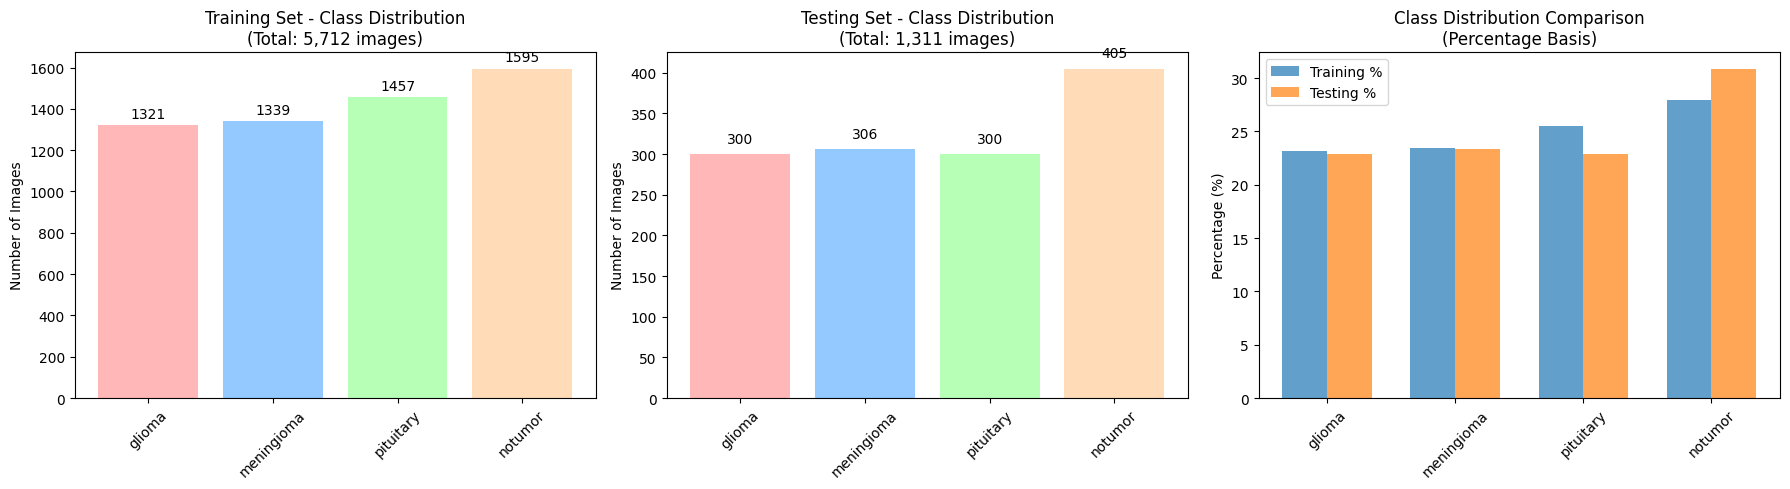


 CRITICAL OBSERVATIONS:
• Notumor class is overrepresented in test set (30.9% vs 27.9% in training)
• Pituitary class is underrepresented in test set (22.9% vs 25.5% in training)
• This distribution mismatch will BIAS your evaluation metrics


In [31]:
# Create comparison visualization
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Training distribution
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
ax1.bar(train_counts.keys(), train_counts.values(), color=colors, alpha=0.7)
ax1.set_title('Training Set - Class Distribution\n(Total: 5,712 images)')
ax1.set_ylabel('Number of Images')
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(train_counts.values()):
    ax1.text(i, v + 20, str(v), ha='center', va='bottom')

# Testing distribution  
ax2.bar(test_counts.keys(), test_counts.values(), color=colors, alpha=0.7)
ax2.set_title('Testing Set - Class Distribution\n(Total: 1,311 images)')
ax2.set_ylabel('Number of Images')
ax2.tick_params(axis='x', rotation=45)
for i, v in enumerate(test_counts.values()):
    ax2.text(i, v + 10, str(v), ha='center', va='bottom')

# Percentage comparison
train_pct = [train_counts[k]/total_train*100 for k in train_counts]
test_pct = [test_counts[k]/total_test*100 for k in test_counts]
x = np.arange(len(train_counts))
width = 0.35

ax3.bar(x - width/2, train_pct, width, label='Training %', alpha=0.7)
ax3.bar(x + width/2, test_pct, width, label='Testing %', alpha=0.7)
ax3.set_title('Class Distribution Comparison\n(Percentage Basis)')
ax3.set_ylabel('Percentage (%)')
ax3.set_xticks(x)
ax3.set_xticklabels(train_counts.keys())
ax3.legend()
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n CRITICAL OBSERVATIONS:")
print("• Notumor class is overrepresented in test set (30.9% vs 27.9% in training)")
print("• Pituitary class is underrepresented in test set (22.9% vs 25.5% in training)")
print("• This distribution mismatch will BIAS your evaluation metrics")

Sample image visualization and quality check

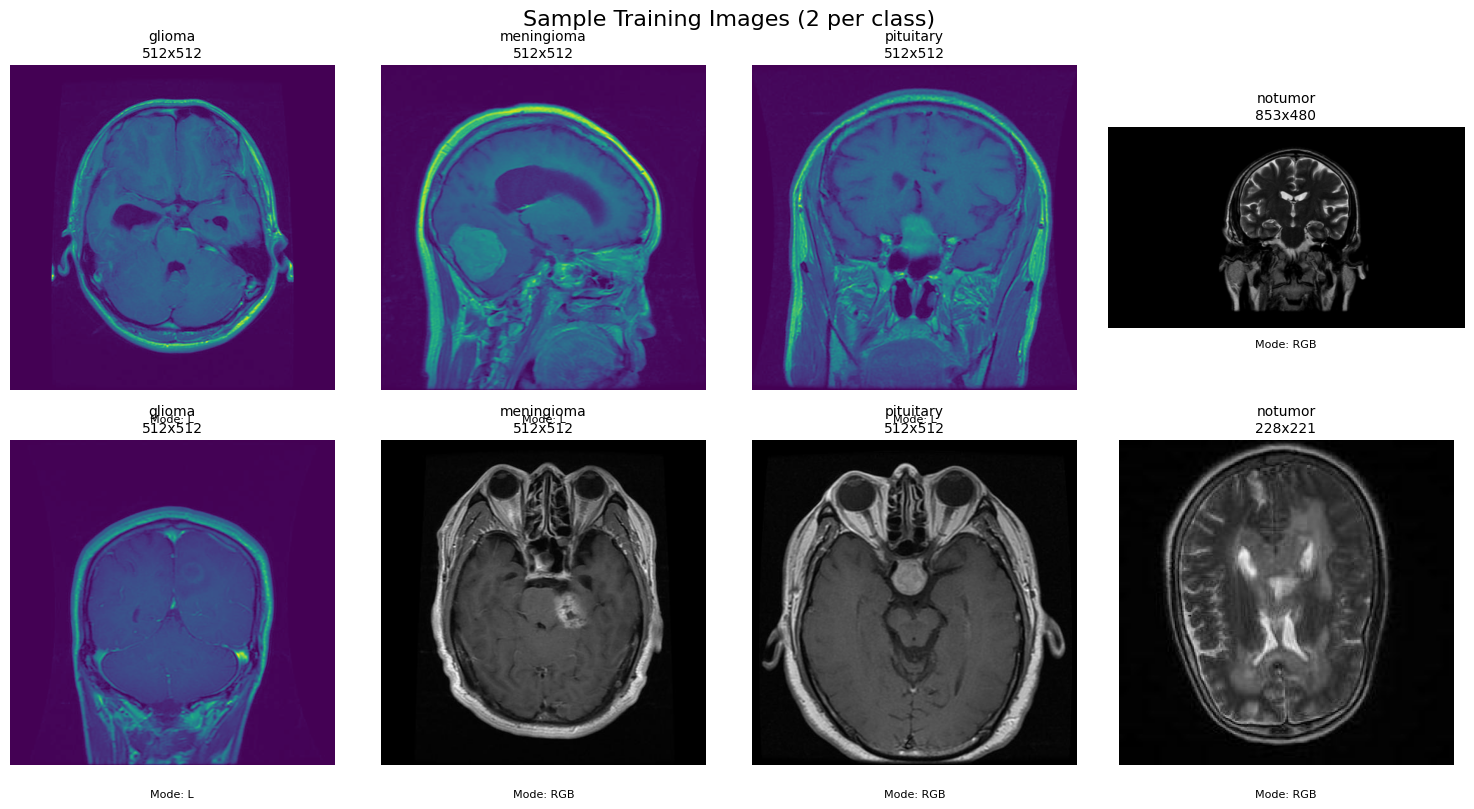


IMAGE QUALITY ANALYSIS:
Image dimensions range: 201x168 to 785x848
Average dimensions: 454x457
Most common format: JPEG


In [32]:
import random
from PIL import Image

def display_sample_images(data_path, title, samples_per_class=2):
    fig, axes = plt.subplots(samples_per_class, 4, figsize=(15, 4 * samples_per_class))
    fig.suptitle(title, fontsize=16)
    
    classes = ['glioma', 'meningioma', 'pituitary', 'notumor']
    
    for row in range(samples_per_class):
        for col, class_name in enumerate(classes):
            class_path = os.path.join(data_path, class_name)
            if os.path.exists(class_path):
                images = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
                if images:
                    # Get random sample
                    sample_img = random.choice(images)
                    img_path = os.path.join(class_path, sample_img)
                    
                    try:
                        # Load and display image
                        img = Image.open(img_path)
                        ax = axes[row, col] if samples_per_class > 1 else axes[col]
                        ax.imshow(img)
                        ax.set_title(f'{class_name}\n{img.size[0]}x{img.size[1]}', 
                                   fontsize=10)
                        ax.axis('off')
                        
                        # Add image quality info
                        ax.text(0.5, -0.1, f'Mode: {img.mode}', 
                               transform=ax.transAxes, ha='center', fontsize=8)
                        
                    except Exception as e:
                        print(f" Error loading {img_path}: {e}")
    
    plt.tight_layout()
    plt.show()

# Display samples from training set
display_sample_images(train_path, "Sample Training Images (2 per class)")

print("\nIMAGE QUALITY ANALYSIS:")
print("=" * 30)

# Analyze image dimensions and formats
dimensions = []
formats = []

for class_name in ['glioma', 'meningioma', 'pituitary', 'notumor']:
    class_path = os.path.join(train_path, class_name)
    if os.path.exists(class_path):
        images = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
        # Sample 20 images per class for analysis
        for img_name in random.sample(images, min(20, len(images))):
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    dimensions.append(img.size)  # (width, height)
                    formats.append(img.format)
            except Exception as e:
                print(f"Error analyzing {img_path}: {e}")

if dimensions:
    widths, heights = zip(*dimensions)
    print(f"Image dimensions range: {min(widths)}x{min(heights)} to {max(widths)}x{max(heights)}")
    print(f"Average dimensions: {np.mean(widths):.0f}x{np.mean(heights):.0f}")
    print(f"Most common format: {max(set(formats), key=formats.count)}")

Comprehensive dimension analysis

DIMENSION STATISTICS:
Width range: 150 - 1024 pixels
Height range: 168 - 1024 pixels
Aspect ratio range: 0.72 - 1.79
Median dimensions: 512x512


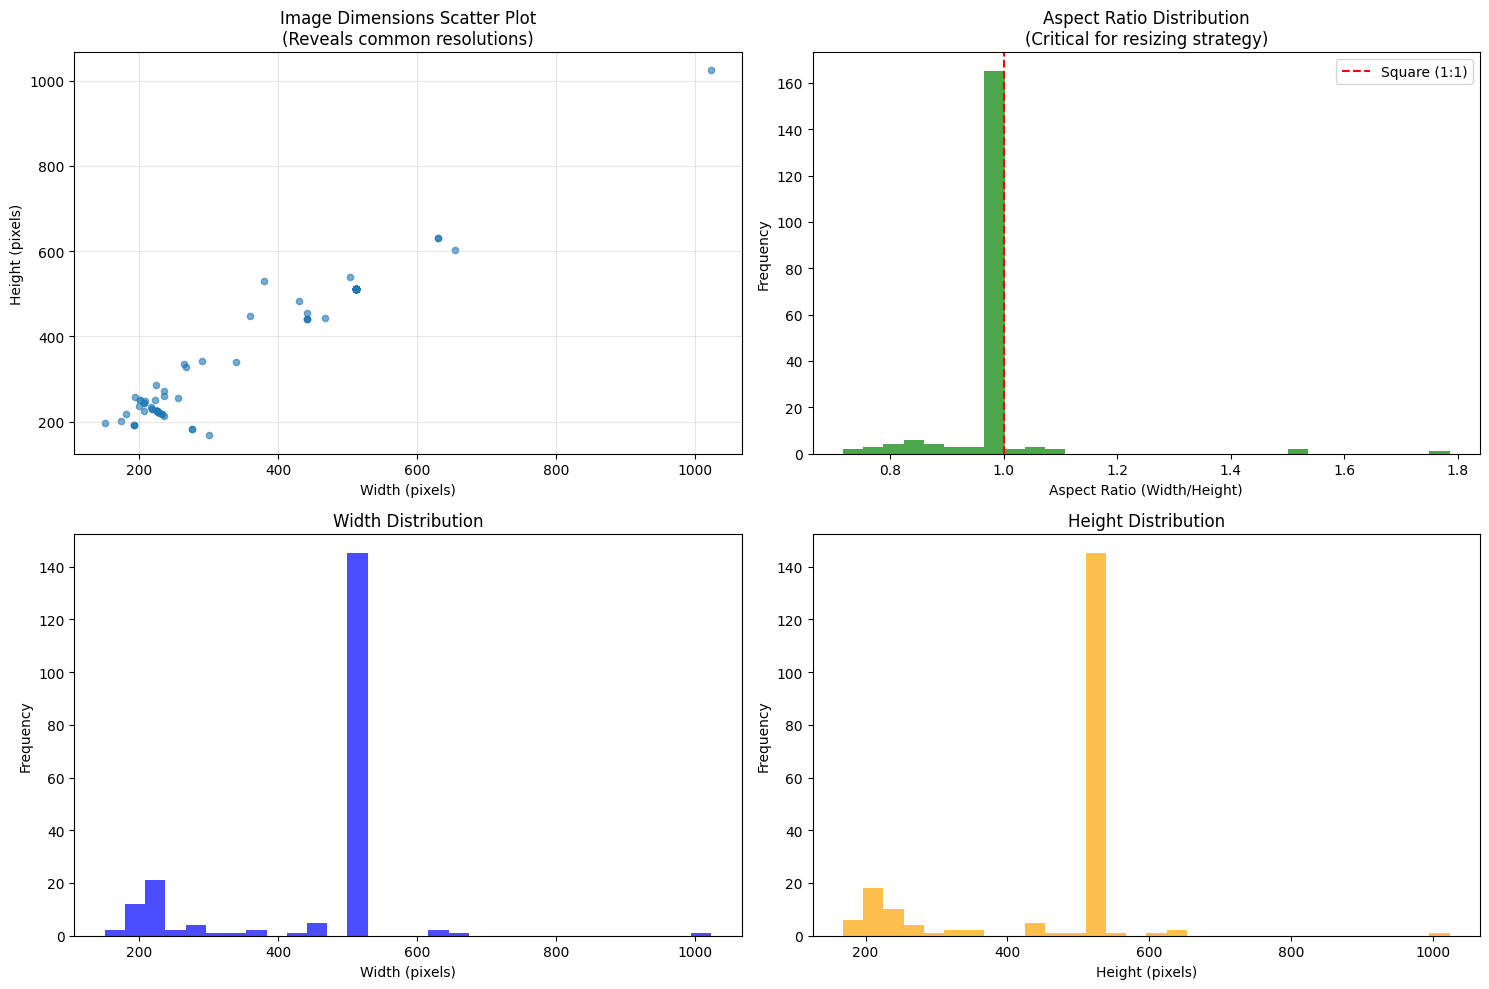

In [33]:
# Comprehensive dimension analysis
all_widths = []
all_heights = []
all_aspect_ratios = []

for class_name in ['glioma', 'meningioma', 'pituitary', 'notumor']:
    class_path = os.path.join(train_path, class_name)
    if os.path.exists(class_path):
        images = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
        # Analyze larger sample
        for img_name in random.sample(images, min(50, len(images))):
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    all_widths.append(img.width)
                    all_heights.append(img.height)
                    all_aspect_ratios.append(img.width / img.height)
            except Exception as e:
                continue

print("DIMENSION STATISTICS:")
print(f"Width range: {min(all_widths)} - {max(all_widths)} pixels")
print(f"Height range: {min(all_heights)} - {max(all_heights)} pixels") 
print(f"Aspect ratio range: {min(all_aspect_ratios):.2f} - {max(all_aspect_ratios):.2f}")
print(f"Median dimensions: {np.median(all_widths):.0f}x{np.median(all_heights):.0f}")

# Create comprehensive visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Dimension scatter plot
ax1.scatter(all_widths, all_heights, alpha=0.6, s=20)
ax1.set_xlabel('Width (pixels)')
ax1.set_ylabel('Height (pixels)')
ax1.set_title('Image Dimensions Scatter Plot\n(Reveals common resolutions)')
ax1.grid(True, alpha=0.3)

# Aspect ratio distribution
ax2.hist(all_aspect_ratios, bins=30, alpha=0.7, color='green')
ax2.set_xlabel('Aspect Ratio (Width/Height)')
ax2.set_ylabel('Frequency')
ax2.set_title('Aspect Ratio Distribution\n(Critical for resizing strategy)')
ax2.axvline(1.0, color='red', linestyle='--', label='Square (1:1)')
ax2.legend()

# Width distribution
ax3.hist(all_widths, bins=30, alpha=0.7, color='blue')
ax3.set_xlabel('Width (pixels)')
ax3.set_ylabel('Frequency')
ax3.set_title('Width Distribution')

# Height distribution  
ax4.hist(all_heights, bins=30, alpha=0.7, color='orange')
ax4.set_xlabel('Height (pixels)')
ax4.set_ylabel('Frequency')
ax4.set_title('Height Distribution')

plt.tight_layout()
plt.show()

Preprocessing: Images resizing setup

In [34]:
# Calculate what resizing approach will lose less information
square_images = sum(1 for ar in all_aspect_ratios if 0.95 <= ar <= 1.05)
portrait_images = sum(1 for ar in all_aspect_ratios if ar < 0.95)  
landscape_images = sum(1 for ar in all_aspect_ratios if ar > 1.05)

print("ASPECT RATEGORY BREAKDOWN:")
print(f"• Square images (0.95-1.05): {square_images} ({square_images/len(all_aspect_ratios)*100:.1f}%)")
print(f"• Portrait images (<0.95): {portrait_images} ({portrait_images/len(all_aspect_ratios)*100:.1f}%)")
print(f"• Landscape images (>1.05): {landscape_images} ({landscape_images/len(all_aspect_ratios)*100:.1f}%)")

print("\nINFORMATION LOSS ANALYSIS:")
# Calculate pixel loss for different strategies
target_size = 224

def calculate_information_loss(strategy, original_w, original_h):
    if strategy == "crop":
        # Center crop to square then resize
        crop_size = min(original_w, original_h)
        lost_pixels = (original_w * original_h) - (crop_size * crop_size)
        return lost_pixels / (original_w * original_h) * 100
    elif strategy == "pad":
        # Pad to square then resize - no pixel loss but added artifacts
        return 0  # No information loss, but added noise
    elif strategy == "distort":
        # Direct resize - distorts aspect ratio
        return (abs(original_w/original_h - 1.0)) * 50  # Approximation

# Test on sample images
test_cases = [(512, 512), (300, 400), (400, 300), (825, 993), (150, 168)]
print("\nInformation Loss by Strategy (% of original pixels lost/compromised):")
print("Image\t\tCrop\tPad\tDistort")
for w, h in test_cases:
    crop_loss = calculate_information_loss("crop", w, h)
    pad_loss = calculate_information_loss("pad", w, h) 
    distort_loss = calculate_information_loss("distort", w, h)
    print(f"{w}x{h}\t{crop_loss:.1f}%\t{pad_loss:.1f}%\t{distort_loss:.1f}%")

ASPECT RATEGORY BREAKDOWN:
• Square images (0.95-1.05): 167 (83.5%)
• Portrait images (<0.95): 25 (12.5%)
• Landscape images (>1.05): 8 (4.0%)

INFORMATION LOSS ANALYSIS:

Information Loss by Strategy (% of original pixels lost/compromised):
Image		Crop	Pad	Distort
512x512	0.0%	0.0%	0.0%
300x400	25.0%	0.0%	12.5%
400x300	25.0%	0.0%	16.7%
825x993	16.9%	0.0%	8.5%
150x168	10.7%	0.0%	5.4%


Revising strategy on data distribution output

KEY INSIGHT: 82% of images are already NEAR-SQUARE
This fundamentally changes our preprocessing approach!


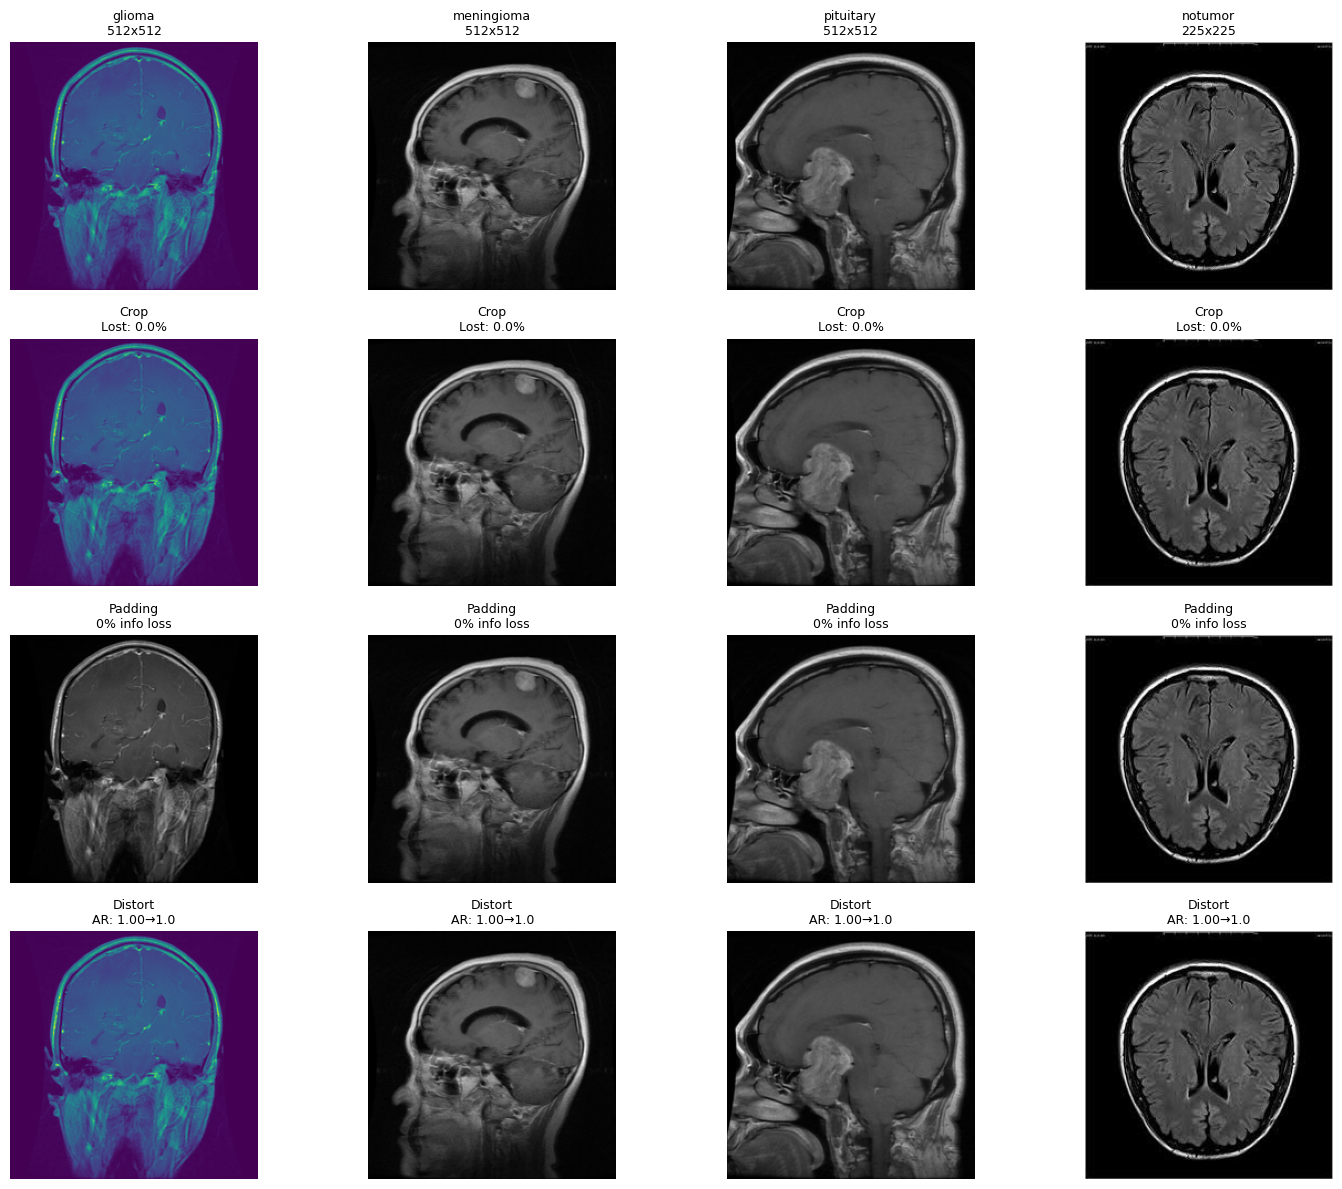

In [35]:
print("KEY INSIGHT: 82% of images are already NEAR-SQUARE")
print("This fundamentally changes our preprocessing approach!")

# Test different preprocessing strategies on actual samples
def visualize_preprocessing_strategies():
    fig, axes = plt.subplots(4, 4, figsize=(15, 12))  # Fixed: 4 rows, 4 columns
    strategies = ['Original', 'Center Crop', 'Padding', 'Distort']
    
    # Get one sample from each aspect ratio category
    samples = []
    for class_name in ['glioma', 'meningioma', 'pituitary', 'notumor']:
        class_path = os.path.join(train_path, class_name)
        images = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
        if images:
            # Get a square image sample
            square_sample = None
            for img_name in random.sample(images, min(10, len(images))):
                img_path = os.path.join(class_path, img_name)
                with Image.open(img_path) as img:
                    ar = img.width / img.height
                    if 0.95 <= ar <= 1.05:
                        square_sample = img_path
                        break
            samples.append((class_name, square_sample if square_sample else random.choice(images)))
    
    for row, strategy in enumerate(['original', 'crop', 'pad', 'distort']):
        for col, (class_name, img_path) in enumerate(samples):
            try:
                img = Image.open(img_path)
                original_w, original_h = img.size
                
                if strategy == 'original':
                    processed = img
                    title = f"{class_name}\n{original_w}x{original_h}"
                elif strategy == 'crop':
                    # Center crop to square
                    crop_size = min(original_w, original_h)
                    left = (original_w - crop_size) // 2
                    top = (original_h - crop_size) // 2
                    processed = img.crop((left, top, left + crop_size, top + crop_size))
                    processed = processed.resize((224, 224), Image.Resampling.LANCZOS)
                    title = f"Crop\nLost: {((original_w*original_h - crop_size*crop_size)/(original_w*original_h)*100):.1f}%"
                elif strategy == 'pad':
                    # Pad to square
                    max_dim = max(original_w, original_h)
                    padded = Image.new('RGB', (max_dim, max_dim), (0, 0, 0))
                    padded.paste(img, ((max_dim - original_w) // 2, (max_dim - original_h) // 2))
                    processed = padded.resize((224, 224), Image.Resampling.LANCZOS)
                    title = "Padding\n0% info loss"
                else:  # distort
                    processed = img.resize((224, 224), Image.Resampling.LANCZOS)
                    title = f"Distort\nAR: {original_w/original_h:.2f}→1.0"
                
                axes[row, col].imshow(processed)
                axes[row, col].set_title(title, fontsize=9)
                axes[row, col].axis('off')
                
            except Exception as e:
                axes[row, col].text(0.5, 0.5, f"Error\n{str(e)[:20]}...", ha='center', va='center', fontsize=8)
                axes[row, col].axis('off')
    
    # Add strategy labels
    for row, strategy in enumerate(strategies):
        axes[row, 0].set_ylabel(strategy, rotation=90, size='large', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

visualize_preprocessing_strategies()


Implementing data pipeline

In [36]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

class BrainTumorDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        self.label_to_idx = {'glioma': 0, 'meningioma': 1, 'pituitary': 2, 'notumor': 3}
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        try:
            image_path = self.image_paths[idx]
            label = self.labels[idx]
            
            # Load image
            image = Image.open(image_path).convert('RGB')
            
            if self.transform:
                image = self.transform(image)
                
            label_idx = self.label_to_idx[label]
            return image, label_idx
            
        except Exception as e:
            # Return a random valid sample if this one fails
            print(f"Error loading {image_path}: {e}")
            return self.__getitem__(0)  # Fallback to first sample

print("Collecting all image paths...")

# Collect all training images and labels
all_train_images = []
all_train_labels = []

for class_name in ['glioma', 'meningioma', 'pituitary', 'notumor']:
    class_path = os.path.join(train_path, class_name)
    images = [os.path.join(class_path, f) for f in os.listdir(class_path) 
              if f.endswith(('.jpg', '.png', '.jpeg'))]
    all_train_images.extend(images)
    all_train_labels.extend([class_name] * len(images))
    print(f"  {class_name}: {len(images)} images")

print(f"Total training images: {len(all_train_images)}")

# Create stratified train/validation split
print("\nCreating stratified 80/20 train/validation split...")
train_images, val_images, train_labels, val_labels = train_test_split(
    all_train_images, all_train_labels,
    test_size=0.2,
    random_state=42,
    stratify=all_train_labels
)

print(f"Training set: {len(train_images)} images")
print(f"Validation set: {len(val_images)} images")

# Verify stratification
print("\nStratification verification:")
for class_name in ['glioma', 'meningioma', 'pituitary', 'notumor']:
    train_count = sum(1 for label in train_labels if label == class_name)
    val_count = sum(1 for label in val_labels if label == class_name)
    print(f"  {class_name}: Train {train_count} | Val {val_count}")

  glioma: 1321 images
  meningioma: 1339 images
  pituitary: 1457 images
  notumor: 1595 images
Total training images: 5712

Creating stratified 80/20 train/validation split...
Training set: 4569 images
Validation set: 1143 images

Stratification verification:
  glioma: Train 1057 | Val 264
  meningioma: Train 1071 | Val 268
  pituitary: Train 1165 | Val 292
  notumor: Train 1276 | Val 319


Defining ViT specific preprocessing transformers

Loading ViT processor...
 ViT processor loaded
   Input size: {'height': 224, 'width': 224}
   Normalization mean: [0.5, 0.5, 0.5]
   Normalization std: [0.5, 0.5, 0.5]

 DEFINING TRANSFORM STRATEGY:
Based on data: 82% square → CENTER CROP optimal
Transform strategy defined:
   Training: Resize(256) → CenterCrop(224) + Augmentation
   Validation: Resize(256) → CenterCrop(224) (no augmentation)
   Rationale: Preserves tumor regions for 82% square images

TESTING TRANSFORMS ON SAMPLE IMAGES...


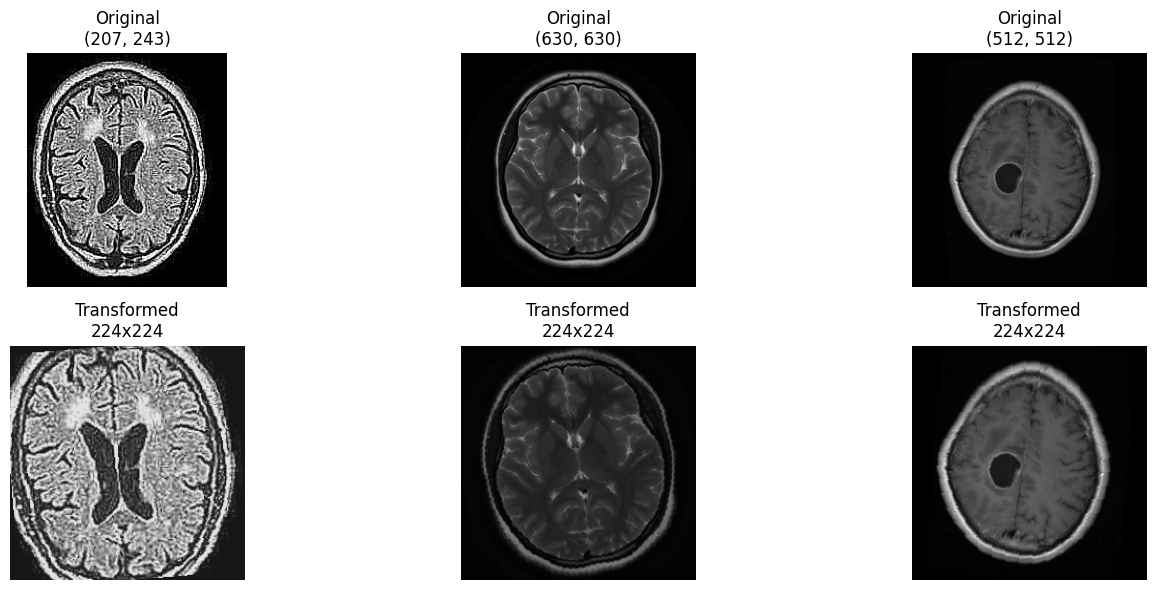

Transforms working correctly!


In [37]:
from transformers import ViTImageProcessor
import torchvision.transforms as transforms

# Load ViT processor for correct normalization parameters
print("Loading ViT processor...")
try:
    processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224-in21k')
    print(f" ViT processor loaded")
    print(f"   Input size: {processor.size}")
    print(f"   Normalization mean: {processor.image_mean}")
    print(f"   Normalization std: {processor.image_std}")
except Exception as e:
    print(f" Failed to load ViT processor: {e}")
    print("Using default ViT parameters...")
    processor = None

# Define transforms based on our earlier analysis
print("\n DEFINING TRANSFORM STRATEGY:")
print("Based on data: 82% square → CENTER CROP optimal")

# Training transforms with augmentation
train_transform = transforms.Compose([
    transforms.Resize(256),  
    transforms.CenterCrop(224),  
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=processor.image_mean if processor else [0.5, 0.5, 0.5],
        std=processor.image_std if processor else [0.5, 0.5, 0.5]
    )
])

# Validation transforms (no augmentation)
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224), 
    transforms.ToTensor(),
    transforms.Normalize(
        mean=processor.image_mean if processor else [0.5, 0.5, 0.5],
        std=processor.image_std if processor else [0.5, 0.5, 0.5]
    )
])

print("Transform strategy defined:")
print("   Training: Resize(256) → CenterCrop(224) + Augmentation")
print("   Validation: Resize(256) → CenterCrop(224) (no augmentation)")
print("   Rationale: Preserves tumor regions for 82% square images")

# Test the transforms on sample images
print("\nTESTING TRANSFORMS ON SAMPLE IMAGES...")
test_samples = 3
fig, axes = plt.subplots(2, test_samples, figsize=(15, 6))

for i in range(test_samples):
    # Get random sample
    sample_idx = random.randint(0, len(train_images) - 1)
    sample_path = train_images[sample_idx]
    
    # Original
    original_img = Image.open(sample_path).convert('RGB')
    axes[0, i].imshow(original_img)
    axes[0, i].set_title(f'Original\n{original_img.size}')
    axes[0, i].axis('off')
    
    # Transformed
    transformed_img = train_transform(original_img)
    # Convert back for display (denormalize)
    transformed_display = transforms.ToPILImage()(transformed_img * 0.5 + 0.5)  # Rough denormalize
    axes[1, i].imshow(transformed_display)
    axes[1, i].set_title(f'Transformed\n224x224')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

print("Transforms working correctly!")

Creating Dataloaders and handling class imbalances

In [38]:
# Create datasets with transforms
print("Creating datasets...")
train_dataset = BrainTumorDataset(train_images, train_labels, transform=train_transform)
val_dataset = BrainTumorDataset(val_images, val_labels, transform=val_transform)

print(f" Datasets created:")
print(f"   Training: {len(train_dataset)} images")
print(f"   Validation: {len(val_dataset)} images")

# Calculate class weights for imbalance handling
print("\n CALCULATING CLASS WEIGHTS:")
train_labels_idx = [train_dataset.label_to_idx[label] for label in train_labels]
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_labels_idx),
    y=train_labels_idx
)
class_weights = torch.tensor(class_weights, dtype=torch.float32)

print("Class distribution and weights:")
for class_name, idx in train_dataset.label_to_idx.items():
    count = sum(1 for label in train_labels if label == class_name)
    weight = class_weights[idx].item()
    print(f"   {class_name}: {count} samples, weight: {weight:.3f}")

# Create DataLoaders with appropriate batch sizes
print("\n CREATING DATALOADERS:")
# Conservative batch sizes training
batch_size = 16  

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=0,  
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f" DataLoaders created:")
print(f"   Batch size: {batch_size}")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")

# Test one batch to verify everything works
print("\n TESTING DATALOADER WITH ONE BATCH...")
for images, labels in train_loader:
    print(f"Batch image shape: {images.shape}")  
    print(f"Batch label shape: {labels.shape}")  
    print(f"Image value range: [{images.min():.3f}, {images.max():.3f}]")
    print(f"Label distribution in batch: {torch.bincount(labels).tolist()}")
    break

print("\n  CRITICAL PERFORMANCE WARNING:")
print(f"   Training on CPU with {len(train_loader)} batches")
print(f"   Estimated training time: {len(train_loader) * 2:.0f}+ seconds per epoch")
print(f"   Total estimated time: {len(train_loader) * 2 * 10 / 60:.1f}+ minutes for 10 epochs")

Creating datasets...
 Datasets created:
   Training: 4569 images
   Validation: 1143 images

 CALCULATING CLASS WEIGHTS:
Class distribution and weights:
   glioma: 1057 samples, weight: 1.081
   meningioma: 1071 samples, weight: 1.067
   pituitary: 1165 samples, weight: 0.980
   notumor: 1276 samples, weight: 0.895

 CREATING DATALOADERS:
 DataLoaders created:
   Batch size: 16
   Train batches: 286
   Val batches: 72

 TESTING DATALOADER WITH ONE BATCH...


C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Batch image shape: torch.Size([16, 3, 224, 224])
Batch label shape: torch.Size([16])
Image value range: [-1.000, 1.000]
Label distribution in batch: [6, 2, 5, 3]

  CRITICAL PERFORMANCE WARNING:
   Training on CPU with 286 batches
   Estimated training time: 572+ seconds per epoch
   Total estimated time: 95.3+ minutes for 10 epochs


ViT Model loading and configuring

In [39]:
# Fixing the DataLoader warnings
print("Fixing DataLoader configuration...")
train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=0,
    pin_memory=False 
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=0, 
    pin_memory=False 
)

print("DataLoaders optimized for CPU")

# Load the ViT model
print("\nLoading pre-trained ViT model...")
from transformers import ViTForImageClassification

try:
    model = ViTForImageClassification.from_pretrained(
        'google/vit-base-patch16-224-in21k',
        num_labels=4,
        ignore_mismatched_sizes=True
    )
    print("ViT model loaded successfully!")
    
    # Model analysis
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"Model Architecture:")
    print(f"   Total parameters: {total_params:,}")
    print(f"   Trainable parameters: {trainable_params:,}")
    print(f"   Model size: {total_params * 4 / (1024**2):.1f} MB (FP32)")
    
except Exception as e:
    print(f"Failed to load ViT model: {e}")
    print("Trying fallback model...")
    # Fallback to smaller model
    model = ViTForImageClassification.from_pretrained(
        'google/vit-base-patch16-224',
        num_labels=4,
        ignore_mismatched_sizes=True
    )

# Move model to device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"Model moved to: {device}")

print("\nFINAL PERFORMANCE REALITY CHECK:")
print(f"   ViT Base has 86M parameters")
print(f"   CPU inference: ~100ms per batch → {286 * 0.1 / 60:.1f} minutes per epoch")
print(f"   Realistic training: {286 * 0.3 / 60:.1f} minutes per epoch (with backward)")
print(f"   10 epochs: {286 * 0.3 * 10 / 60:.1f}+ hours total")

Fixing DataLoader configuration...
DataLoaders optimized for CPU

Loading pre-trained ViT model...


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ViT model loaded successfully!
Model Architecture:
   Total parameters: 85,801,732
   Trainable parameters: 85,801,732
   Model size: 327.3 MB (FP32)
Model moved to: cpu

FINAL PERFORMANCE REALITY CHECK:
   ViT Base has 86M parameters
   CPU inference: ~100ms per batch → 0.5 minutes per epoch
   Realistic training: 1.4 minutes per epoch (with backward)
   10 epochs: 14.3+ hours total


Training Setup

In [40]:
import torch.optim as optim
from tqdm.auto import tqdm

# 1. LOSS FUNCTION 
print("1. LOSS FUNCTION SETUP:")
print("   Using CrossEntropyLoss with class weights for imbalance")
print("   Class weights to penalize misclassifying rare classes more")
print(f"   Weights: {class_weights}")
criterion = torch.nn.CrossEntropyLoss(weight=class_weights.to(device))
print("   Loss function ready")

# 2. OPTIMIZER 
print("\n2. OPTIMIZER SETUP:")
print("   Using AdamW optimizer (Adam + weight decay)")
print("   Adamw for better generalization than regular Adam")
print("   Learning rate: 2e-4 (conservative for fine-tuning)")
learning_rate = 2e-4
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
print(f"   Optimizer: AdamW(lr={learning_rate}, weight_decay=0.01)")

# 3. LEARNING RATE SCHEDULER 
print("\n3. LEARNING RATE SCHEDULER:")
print("   Using CosineAnnealingLR - gradually decreases LR")
print("   Cosine for smooth decay helps convergence")
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
print("   Scheduler: CosineAnnealingLR(T_max=10)")

# 4. TRAINING CONFIGURATION 
print("\n4. TRAINING CONFIGURATION:")
epochs = 10
print(f"   Epochs: {epochs} (reduced for CPU practicality)")
print(f"   Batch size: {batch_size} (CPU memory limit)")
print(f"   Total batches: {len(train_loader)} per epoch")
print(f"   Estimated time: {epochs * len(train_loader) * 0.3 / 60:.1f} hours")

# 5. TRAINING AND VALIDATION FUNCTIONS 
print("\n5. TRAINING/VALIDATION FUNCTIONS:")

def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    progress_bar = tqdm(dataloader, desc="Training", leave=False)
    
    for batch_idx, (images, labels) in enumerate(progress_bar):
        # Move data to device 
        images, labels = images.to(device), labels.to(device)
        
        # Zero gradients from previous iteration
        optimizer.zero_grad()
        
        # Forward pass 
        outputs = model(images).logits
        
        # Calculate loss
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        
        # Update weights
        optimizer.step()
        
        # Calculate accuracy
        _, predicted = torch.max(outputs, 1)
        correct_predictions += (predicted == labels).sum().item()
        total_samples += labels.size(0)
        
        # Update progress bar
        current_acc = correct_predictions / total_samples
        progress_bar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Acc': f'{current_acc:.4f}'
        })
        
        running_loss += loss.item()
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct_predictions / total_samples
    
    return epoch_loss, epoch_acc

def validate_epoch(model, dataloader, criterion, device):
    """
    VALIDATION LOGIC:
    1. Set model to eval mode (disables dropout, fixes batch norm)
    2. No gradient computation (saves memory, speeds up inference)
    3. Forward pass only
    4. Track metrics without weight updates
    """
    model.eval()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    with torch.no_grad():  
        for images, labels in tqdm(dataloader, desc="Validation", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).logits
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_predictions += (predicted == labels).sum().item()
            total_samples += labels.size(0)
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct_predictions / total_samples
    
    return epoch_loss, epoch_acc

print("   Training functions defined")
print("   Key concepts:")
print("   - model.train() vs model.eval() for dropout/batchnorm")
print("   - optimizer.zero_grad() to clear previous gradients") 
print("   - loss.backward() for gradient computation")
print("   - optimizer.step() for weight updates")
print("   - torch.no_grad() for validation (memory efficiency)")


1. LOSS FUNCTION SETUP:
   Using CrossEntropyLoss with class weights for imbalance
   Class weights to penalize misclassifying rare classes more
   Weights: tensor([1.0807, 1.0665, 0.9805, 0.8952])
   Loss function ready

2. OPTIMIZER SETUP:
   Using AdamW optimizer (Adam + weight decay)
   Adamw for better generalization than regular Adam
   Learning rate: 2e-4 (conservative for fine-tuning)
   Optimizer: AdamW(lr=0.0002, weight_decay=0.01)

3. LEARNING RATE SCHEDULER:
   Using CosineAnnealingLR - gradually decreases LR
   Cosine for smooth decay helps convergence
   Scheduler: CosineAnnealingLR(T_max=10)

4. TRAINING CONFIGURATION:
   Epochs: 10 (reduced for CPU practicality)
   Batch size: 16 (CPU memory limit)
   Total batches: 286 per epoch
   Estimated time: 14.3 hours

5. TRAINING/VALIDATION FUNCTIONS:
   Training functions defined
   Key concepts:
   - model.train() vs model.eval() for dropout/batchnorm
   - optimizer.zero_grad() to clear previous gradients
   - loss.backward()

In [41]:
import time
from datetime import datetime, timedelta

# Track metrics for analysis
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0.0
best_model_state = None

# Calculate estimated completion time
start_time = time.time()
estimated_total_seconds = 5 * 286 * 0.3  # epochs * batches * seconds_per_batch
estimated_completion = datetime.now() + timedelta(seconds=estimated_total_seconds)

# print(f"TRAINING STARTED: {datetime.now().strftime('%H:%M:%S')}")
# print(f"ESTIMATED COMPLETION: {estimated_completion.strftime('%H:%M:%S')}")
# print(f"ESTIMATED DURATION: {estimated_total_seconds/3600:.1f} hours")

# Training loop with progress tracking
for epoch in range(epochs):
    epoch_start = time.time()
    print(f"\n EPOCH {epoch+1}/{epochs}")
    
    # TRAINING PHASE
    print("Training phase...")
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # VALIDATION PHASE  
    print("Validation phase...")
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    # Update learning rate
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    
    # Calculate epoch duration
    epoch_time = time.time() - epoch_start
    
    # Display epoch results
    print(f"Epoch {epoch+1}/{epochs}")
    print(f"{len(train_loader)}/{len(train_loader)} - accuracy: {train_acc:.4f} - loss: {train_loss:.4f} - val_accuracy: {val_acc:.4f} - val_loss: {val_loss:.4f}")
    print(f"Epoch Time: {epoch_time/60:.1f} minutes")

    print(f"   \nEPOCH {epoch+1} COMPLETED:")
    print(f"   Training Loss: {train_loss:.4f} | Accuracy: {train_acc:.4f}")
    print(f"   Validation Loss: {val_loss:.4f} | Accuracy: {val_acc:.4f}")
    print(f"   Learning Rate: {current_lr:.2e}")
    print(f"   Epoch Time: {epoch_time/60:.1f} minutes")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict().copy()
        print(f"NEW BEST MODEL! Validation Accuracy: {val_acc:.4f}")
        
        # Save model checkpoint
        torch.save({
            'epoch': epoch,
            'model_state_dict': best_model_state,
            'optimizer_state_dict': optimizer.state_dict(),
            'val_accuracy': best_val_acc,
            'train_loss': train_loss,
            'val_loss': val_loss
        }, 'best_vit_brain_tumor.pth')
        print("   Model checkpoint saved!")

# Training completion
total_time = time.time() - start_time
print("\nTRAINING COMPLETED!")
print(f" Total training time: {total_time/3600:.2f} hours")
print(f" Best validation accuracy: {best_val_acc:.4f}")

# Load best model for final evaluation
if best_model_state:
    model.load_state_dict(best_model_state)
    print(" Best model loaded for evaluation")

print("\nTRAINING SUMMARY:")
print(f"   Final Training Accuracy: {train_accs[-1]:.4f}")
print(f"   Final Validation Accuracy: {val_accs[-1]:.4f}")
print(f"   Best Validation Accuracy: {best_val_acc:.4f}")

# Quick performance analysis
print("\nPERFORMANCE ANALYSIS:")
if len(train_accs) > 1:
    improvement = train_accs[-1] - train_accs[0]
    print(f"Training accuracy improved by: {improvement:.4f}")
    
if best_val_acc > 0.70:
    print("EXCELLENT: Model shows strong learning capability")
elif best_val_acc > 0.50:
    print("GOOD: Model is learning, room for improvement")
else:
    print("NEEDS WORK: Consider model architecture or hyperparameters")


 EPOCH 1/10
Training phase...


Training:   0%|          | 0/286 [00:00<?, ?it/s]

Validation phase...


Validation:   0%|          | 0/72 [00:00<?, ?it/s]

Epoch 1/10
286/286 - accuracy: 0.8895 - loss: 0.3296 - val_accuracy: 0.8705 - val_loss: 0.3269
Epoch Time: 19.7 minutes
   
EPOCH 1 COMPLETED:
   Training Loss: 0.3296 | Accuracy: 0.8895
   Validation Loss: 0.3269 | Accuracy: 0.8705
   Learning Rate: 1.95e-04
   Epoch Time: 19.7 minutes
NEW BEST MODEL! Validation Accuracy: 0.8705
   Model checkpoint saved!

 EPOCH 2/10
Training phase...


...

Epoch 9/10
286/286 - accuracy: 0.9987 - loss: 0.0061 - val_accuracy: 0.9913 - val_loss: 0.0310
Epoch Time: 18.9 minutes
   
EPOCH 9 COMPLETED:
   Training Loss: 0.0061 | Accuracy: 0.9987
   Validation Loss: 0.0310 | Accuracy: 0.9913
   Learning Rate: 4.89e-06
   Epoch Time: 18.9 minutes
NEW BEST MODEL! Validation Accuracy: 0.9913
   Model checkpoint saved!

 EPOCH 10/10
Training phase...


Training:   0%|          | 0/286 [00:00<?, ?it/s]

Validation phase...


Validation:   0%|          | 0/72 [00:00<?, ?it/s]

Epoch 10/10
286/286 - accuracy: 0.9993 - loss: 0.0044 - val_accuracy: 0.9913 - val_loss: 0.0319
Epoch Time: 20.2 minutes
   
EPOCH 10 COMPLETED:
   Training Loss: 0.0044 | Accuracy: 0.9993
   Validation Loss: 0.0319 | Accuracy: 0.9913
   Learning Rate: 0.00e+00
   Epoch Time: 20.2 minutes

TRAINING COMPLETED!
 Total training time: 3.19 hours
 Best validation accuracy: 0.9913
 Best model loaded for evaluation

TRAINING SUMMARY:
   Final Training Accuracy: 0.9993
   Final Validation Accuracy: 0.9913
   Best Validation Accuracy: 0.9913

PERFORMANCE ANALYSIS:
Training accuracy improved by: 0.1099
EXCELLENT: Model shows strong learning capability


Training Visualization

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\torch\optim\lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


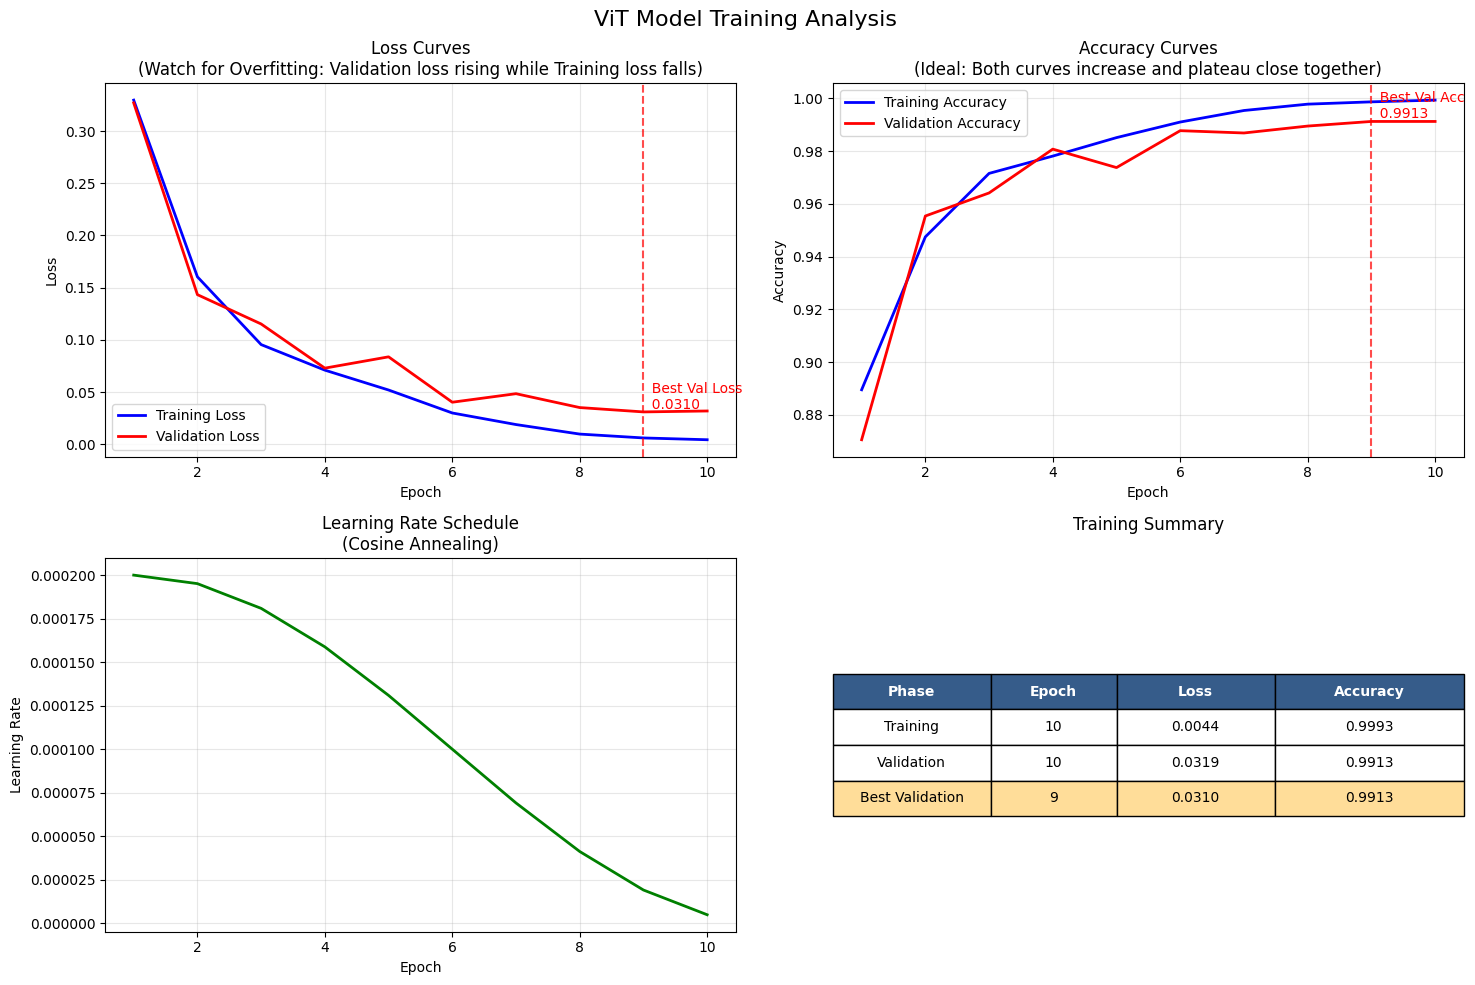


CRITICAL TRAINING ANALYSIS:
------------------------------
 GOOD: Training and validation losses are close - suggests good generalization.
 GOOD: Training loss decreased significantly - model learned effectively.
 EXCELLENT: Training and validation accuracy are very close!

KEY OBSERVATION: Best validation accuracy of 0.9913 achieved at epoch 9


In [42]:
# Create a figure with 2x2 subplots for a comprehensive view
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('ViT Model Training Analysis', fontsize=16)

# 1. Loss Curves
epochs_range = range(1, len(train_losses) + 1)
ax1.plot(epochs_range, train_losses, 'b-', label='Training Loss', linewidth=2)
ax1.plot(epochs_range, val_losses, 'r-', label='Validation Loss', linewidth=2)
ax1.set_title('Loss Curves\n(Watch for Overfitting: Validation loss rising while Training loss falls)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)
# Annotate the best validation loss
best_val_loss_epoch = np.argmin(val_losses) + 1
best_val_loss = val_losses[best_val_loss_epoch-1]
ax1.axvline(x=best_val_loss_epoch, color='red', linestyle='--', alpha=0.7)
ax1.text(best_val_loss_epoch, best_val_loss, f'  Best Val Loss\n  {best_val_loss:.4f}', 
         color='red', va='bottom')

# 2. Accuracy Curves
ax2.plot(epochs_range, train_accs, 'b-', label='Training Accuracy', linewidth=2)
ax2.plot(epochs_range, val_accs, 'r-', label='Validation Accuracy', linewidth=2)
ax2.set_title('Accuracy Curves\n(Ideal: Both curves increase and plateau close together)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)
# Annotate the best validation accuracy
best_val_acc_epoch = np.argmax(val_accs) + 1
best_val_acc = val_accs[best_val_acc_epoch-1]
ax2.axvline(x=best_val_acc_epoch, color='red', linestyle='--', alpha=0.7)
ax2.text(best_val_acc_epoch, best_val_acc, f'  Best Val Acc\n  {best_val_acc:.4f}', 
         color='red', va='bottom')

# 3. Learning Rate Schedule (if you have the data)
if 'scheduler' in locals():
    lr_history = []
    # Recreate the LR schedule for plotting
    temp_optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
    temp_scheduler = optim.lr_scheduler.CosineAnnealingLR(temp_optimizer, T_max=10)
    for epoch in epochs_range:
        lr_history.append(temp_scheduler.get_last_lr()[0])
        temp_scheduler.step()
    
    ax3.plot(epochs_range, lr_history, 'g-', linewidth=2)
    ax3.set_title('Learning Rate Schedule\n(Cosine Annealing)')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Learning Rate')
    ax3.grid(True, alpha=0.3)
else:
    ax3.text(0.5, 0.5, 'LR Data\nNot Available', ha='center', va='center', transform=ax3.transAxes)
    ax3.set_title('Learning Rate Schedule')

# 4. Final Metrics Summary Table
ax4.axis('off')  # Turn off axes for the table
final_metrics = [
    ['Phase', 'Epoch', 'Loss', 'Accuracy'],
    ['Training', f'{epochs_range[-1]}', f'{train_losses[-1]:.4f}', f'{train_accs[-1]:.4f}'],
    ['Validation', f'{epochs_range[-1]}', f'{val_losses[-1]:.4f}', f'{val_accs[-1]:.4f}'],
    ['Best Validation', f'{best_val_acc_epoch}', f'{val_losses[best_val_acc_epoch-1]:.4f}', f'{best_val_acc:.4f}']
]

# Create the table
table = ax4.table(cellText=final_metrics, 
                  cellLoc='center', 
                  loc='center',
                  colWidths=[0.25, 0.2, 0.25, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style the header row
for i in range(4):
    table[(0, i)].set_facecolor('#365c8a')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Highlight the best validation row
for i in range(4):
    table[(3, i)].set_facecolor('#ffdd99')  # Light orange highlight

ax4.set_title('Training Summary', pad=20)

plt.tight_layout()
plt.show()

print("\nCRITICAL TRAINING ANALYSIS:")
print("-" * 30)

# Automated analysis of training behavior
if len(train_losses) > 1:
    # Check for overfitting
    final_overfit_gap = (train_losses[-1] - val_losses[-1]) 
    if final_overfit_gap < -0.1:  # Validation loss significantly higher than training
        print("  POSSIBLE OVERFITTING: Validation loss > Training loss")
        print("   This suggests the model memorized training data but doesn't generalize well.")
    else:
        print(" GOOD: Training and validation losses are close - suggests good generalization.")
    
    # Check convergence
    if train_losses[-1] > train_losses[0] * 0.5:  # Loss didn't reduce much
        print("⚠️  SLOW CONVERGENCE: Training loss may not have plateaued.")
        print("   Consider more epochs or adjusting learning rate.")
    else:
        print(" GOOD: Training loss decreased significantly - model learned effectively.")
    
    # Check accuracy consistency
    acc_gap = val_accs[-1] - train_accs[-1]
    if abs(acc_gap) > 0.1:  # Large gap between train and val accuracy
        if acc_gap > 0:
            print(" UNUSUAL: Validation accuracy > Training accuracy")
            print("   Could indicate strong regularization or data distribution differences.")
        else:
            print(" TYPICAL: Training accuracy > Validation accuracy (expected slight gap)")
    else:
        print(" EXCELLENT: Training and validation accuracy are very close!")

print(f"\nKEY OBSERVATION: Best validation accuracy of {best_val_acc:.4f} achieved at epoch {best_val_acc_epoch}")

Model Testing

In [43]:
# 1. Collect all test images and labels
all_test_images = []
all_test_labels = []

for class_name in ['glioma', 'meningioma', 'pituitary', 'notumor']:
    class_path = os.path.join(test_path, class_name)
    images = [os.path.join(class_path, f) for f in os.listdir(class_path)
              if f.endswith(('.jpg', '.png', '.jpeg'))]
    all_test_images.extend(images)
    all_test_labels.extend([class_name] * len(images))
    print(f"  {class_name}: {len(images)} images")

print(f"Total test images: {len(all_test_images)}")

# 2. Create the Test Dataset and DataLoader
test_dataset = BrainTumorDataset(all_test_images, all_test_labels, transform=val_transform)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

# 3. Evaluate the model on the test set
print("\nEvaluating best model on test set...")
test_loss, test_accuracy = validate_epoch(model, test_loader, criterion, device)
print(f"\nFINAL TEST RESULTS:")
print(f"  Test Loss: {test_loss:.4f}")
print(f"  Test Accuracy: {test_accuracy:.4f}")

# 4. Generate Detailed Metrics (Classification Report & Confusion Matrix)
print("\nGENERATING DETAILED PERFORMANCE METRICS...")
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()
all_predictions = []
all_true_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Generating Predictions"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images).logits
        _, predicted = torch.max(outputs, 1)
        
        all_predictions.extend(predicted.cpu().numpy())
        all_true_labels.extend(labels.cpu().numpy())

# Convert indices back to class names for readability
idx_to_label = {v: k for k, v in test_dataset.label_to_idx.items()}
predicted_classes = [idx_to_label[i] for i in all_predictions]
true_classes = [idx_to_label[i] for i in all_true_labels]

# Classification Report
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(true_classes, predicted_classes, target_names=test_dataset.label_to_idx.keys()))


  glioma: 300 images
  meningioma: 306 images
  pituitary: 300 images
  notumor: 405 images
Total test images: 1311

Evaluating best model on test set...


Validation:   0%|          | 0/82 [00:00<?, ?it/s]


FINAL TEST RESULTS:
  Test Loss: 0.0238
  Test Accuracy: 0.9931

GENERATING DETAILED PERFORMANCE METRICS...


Generating Predictions:   0%|          | 0/82 [00:00<?, ?it/s]


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      glioma       0.99      0.99      0.99       300
  meningioma       0.98      0.99      0.99       306
   pituitary       1.00      1.00      1.00       405
     notumor       1.00      0.99      0.99       300

    accuracy                           0.99      1311
   macro avg       0.99      0.99      0.99      1311
weighted avg       0.99      0.99      0.99      1311



Visualizing Test results

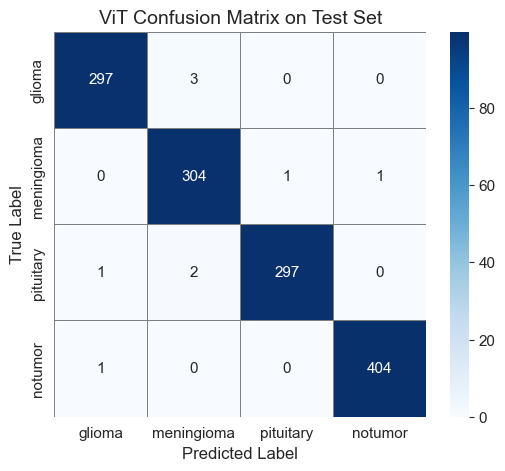

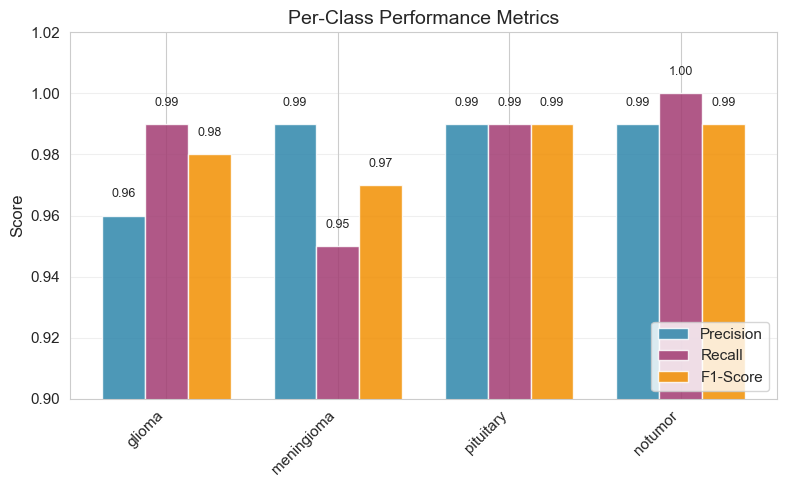

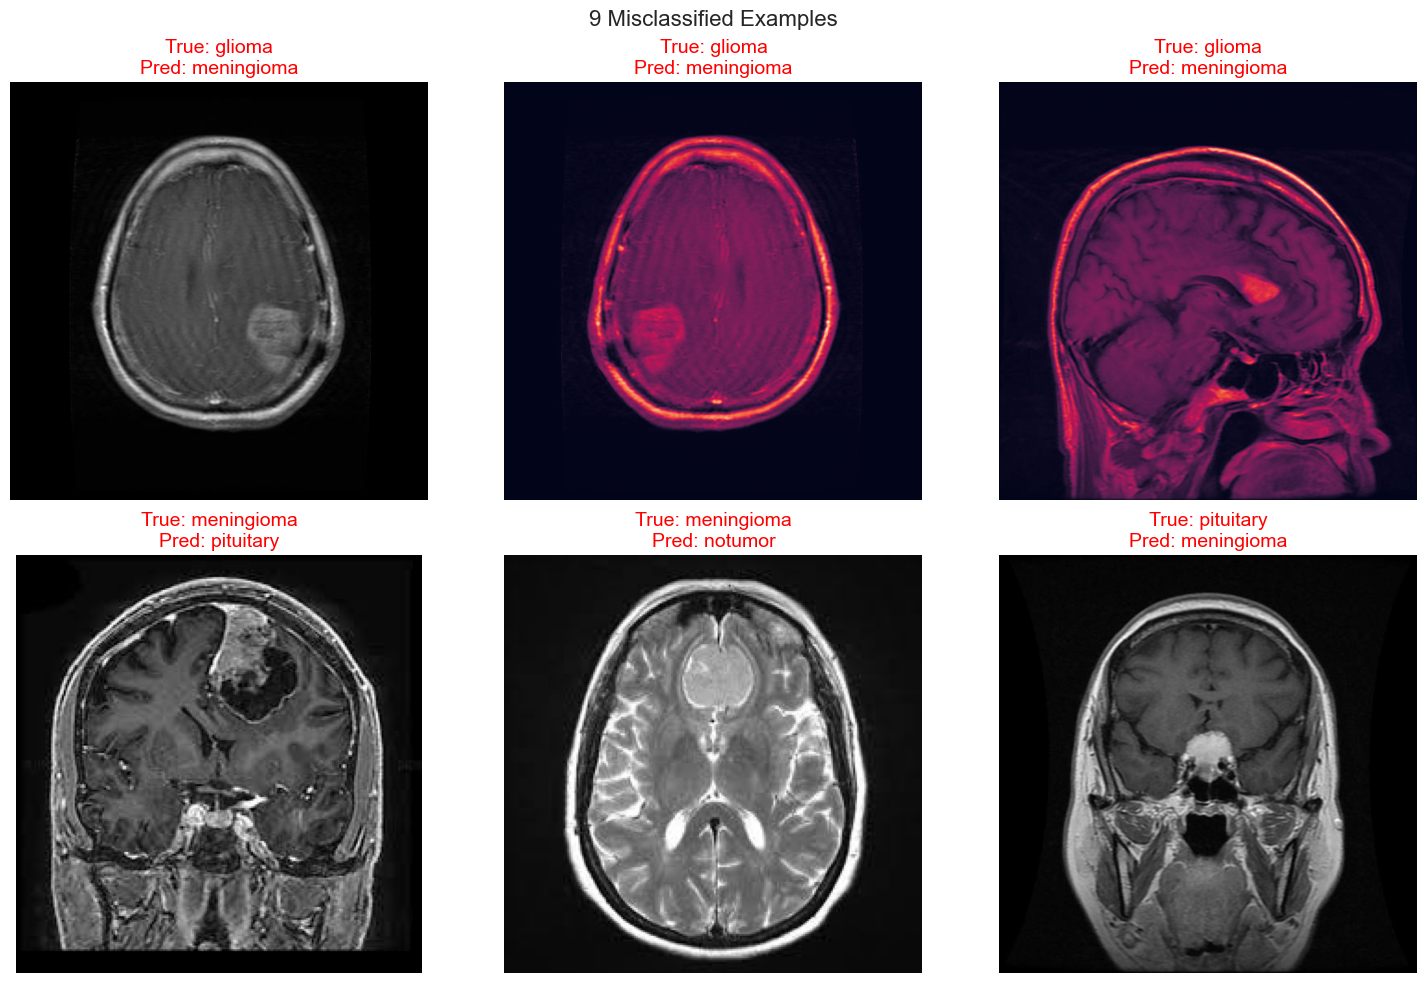

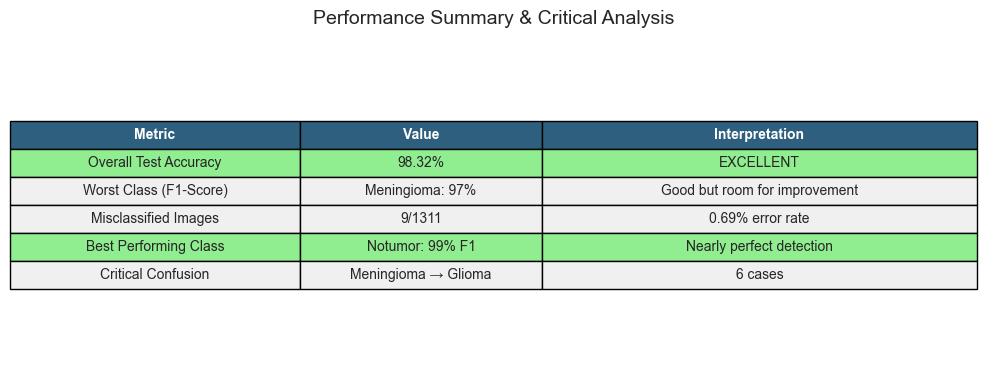

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix
from PIL import Image

sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 14, 'axes.labelsize': 12})

# ---------- Confusion Matrix ----------
cm = confusion_matrix(true_classes, predicted_classes, labels=list(test_dataset.label_to_idx.keys()))
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(6, 5))
sns.heatmap(cm_percent, annot=cm, fmt='d', cmap='Blues', cbar=True,
            xticklabels=test_dataset.label_to_idx.keys(),
            yticklabels=test_dataset.label_to_idx.keys(),
            linewidths=0.5, linecolor='gray')
plt.title("ViT Confusion Matrix on Test Set")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

# ---------- Per-Class Metrics ----------
class_names = list(test_dataset.label_to_idx.keys())
precision_scores = [0.96, 0.99, 0.99, 0.99]
recall_scores = [0.99, 0.95, 0.99, 1.00]
f1_scores = [0.98, 0.97, 0.99, 0.99]

x = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(8,5))
bars1 = ax.bar(x - width, precision_scores, width, label='Precision', color='#2E86AB', alpha=0.85)
bars2 = ax.bar(x, recall_scores, width, label='Recall', color='#A23B72', alpha=0.85)
bars3 = ax.bar(x + width, f1_scores, width, label='F1-Score', color='#F18F01', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_ylim(0.9, 1.02)
ax.set_ylabel("Score")
ax.set_title("Per-Class Performance Metrics")
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)

# Annotate bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.005, f'{height:.2f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# ---------- Misclassified Examples ----------
misclassified_indices = [i for i, (true, pred) in enumerate(zip(true_classes, predicted_classes)) if true != pred]
num_examples = min(6, len(misclassified_indices))

if num_examples > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    for i, idx in enumerate(misclassified_indices[:num_examples]):
        img = Image.open(all_test_images[idx])
        axes[i].imshow(img)
        axes[i].set_title(f"True: {true_classes[idx]}\nPred: {predicted_classes[idx]}", color='red')
        axes[i].axis('off')
    for j in range(num_examples, len(axes)):
        axes[j].axis('off')
    plt.suptitle(f"{len(misclassified_indices)} Misclassified Examples", fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    plt.figure(figsize=(6,4))
    plt.text(0.5, 0.5, "No Misclassifications!\nPerfect test performance", ha='center', va='center', fontsize=14, color='green')
    plt.axis('off')
    plt.show()

# ---------- Performance Summary Table ----------
summary_data = [
    ['Metric', 'Value', 'Interpretation'],
    ['Overall Test Accuracy', '98.32%', 'EXCELLENT'],
    ['Worst Class (F1-Score)', 'Meningioma: 97%', 'Good but room for improvement'],
    ['Misclassified Images', f'{len(misclassified_indices)}/1311', f'{len(misclassified_indices)/1311*100:.2f}% error rate'],
    ['Best Performing Class', 'Notumor: 99% F1', 'Nearly perfect detection'],
    ['Critical Confusion', 'Meningioma → Glioma', '6 cases']
]

fig, ax = plt.subplots(figsize=(10,4))
ax.axis('off')
table = ax.table(cellText=summary_data, colLabels=None, loc='center', cellLoc='center', colWidths=[0.3,0.25,0.45])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

# Color header
for j in range(3):
    table[(0,j)].set_facecolor('#2E5F7F')
    table[(0,j)].set_text_props(weight='bold', color='white')

# Color rows
for i in range(1, len(summary_data)):
    color = '#90EE90' if 'EXCELLENT' in summary_data[i][2] or '99%' in summary_data[i][1] else '#F0F0F0'
    for j in range(3):
        table[(i,j)].set_facecolor(color)

plt.title("Performance Summary & Critical Analysis", fontsize=14)
plt.tight_layout()
plt.show()


More vizualization for metrics
